In [ ]:
!pip install pandas

In [ ]:
!pip install matplotlib

In [56]:
import pandas as pd
import math
from phe import paillier
from haversine import haversine


# Load the dataset
data = pd.read_csv("names.csv") 
display(data.head(10))
# Geofence parameters
center_lat = 50.375618
center_lon = -4.139433
geofence_radius = 0.3  # km

# Step 1: Key Generation 
public_key, private_key = paillier.generate_paillier_keypair()

# Define a function for privacy-preserving haversine distance
def is_within_geofence(center_lat, center_lon, geofence_radius, data_latitude, data_longtitude):
    # Convert degrees to radians
    latA = math.radians(center_lat)
    lonA = math.radians(center_lon)
    latB = math.radians(data_latitude)
    lonB = math.radians(data_longtitude)

    # Compute trigonometric values
    alpha = math.cos(latA / 2)
    beta = math.sin(latB / 2)
    gamma = math.sin(latA / 2)
    delta = math.cos(latB / 2)
    zeta = math.cos(latA)
    eta = math.cos(latB)
    theta = math.sin(lonA / 2)
    lambda_ = math.cos(lonB / 2)
    mu = math.cos(lonA / 2)
    nu = math.sin(lonB / 2)

    # Computes encrypted values
    enc_alpha_squared = public_key.encrypt(alpha**2)
    enc_neg_two_alpha_gamma = public_key.encrypt(-2 * alpha * gamma)
    enc_gamma_squared = public_key.encrypt(gamma**2)
    enc_zeta_eta_theta_lambda_squared = public_key.encrypt(zeta * eta * (theta**2) * (lambda_**2))
    enc_neg_two_zeta_eta_theta_lambda = public_key.encrypt(-2 * zeta * eta * theta * lambda_)
    enc_zeta_mu = public_key.encrypt(zeta * mu**2)

    # Computes encrypted distance
    beta_squared = beta**2
    delta_squared = delta**2
    mu_nu = mu * nu
    eta_nu_squared = eta * nu**2

    enc_a = (
        enc_alpha_squared * beta_squared +
        enc_neg_two_alpha_gamma * (beta * delta) +
        enc_gamma_squared * delta_squared +
        enc_zeta_eta_theta_lambda_squared +
        enc_neg_two_zeta_eta_theta_lambda * mu_nu +
        enc_zeta_mu * eta_nu_squared
    )

    # Decrypts a
    a = private_key.decrypt(enc_a)

    # Compute haversine distance
    R = 6371.0 
    distance = 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return distance <= geofence_radius, distance

# List to store results
results = []

# Iterate through the dataset
for _, row in data.iterrows():
    data_latitude = row['latitude']
    data_longtitude = row['longitude']

    inside, dist = is_within_geofence(center_lat, center_lon, geofence_radius, data_latitude, data_longtitude)

    # Validate using standard haversine library
    haversine_distance = haversine((center_lat, center_lon), (data_latitude, data_longtitude))

    results.append({
        "name": row["name"],
        "latitude": data_latitude,
        "longitude": data_longtitude,
        "haversine distance": round(haversine_distance, 2),
        "distance" : round(dist, 2),
        "status": "INSIDE" if inside else "OUTSIDE"
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Print table
print(results_df)



,name,latitude,longitude
0,callum,50.37337,-4.134360
1,hai-van,50.37358,-4.135230
2,oliver,50.37364,-4.143980
3,arnas,50.37460,-4.141950
4,arka,50.37800,-4.145770
5,stanley,50.37857,-4.144720
6,myles,50.37819,-4.134780
7,jessy,50.37210,-4.139800
8,nathan,50.37917,-4.135475
9,rory,50.38048,-4.133210


       name  latitude  longitude  haversine distance  distance   status
0    callum  50.37337  -4.134360                0.44      0.44  OUTSIDE
1   hai-van  50.37358  -4.135230                0.37      0.37  OUTSIDE
2    oliver  50.37364  -4.143980                0.39      0.39  OUTSIDE
3     arnas  50.37460  -4.141950                0.21      0.21   INSIDE
4      arka  50.37800  -4.145770                0.52      0.52  OUTSIDE
5   stanley  50.37857  -4.144720                0.50      0.50  OUTSIDE
6     myles  50.37819  -4.134780                0.44      0.44  OUTSIDE
7     jessy  50.37210  -4.139800                0.39      0.39  OUTSIDE
8    nathan  50.37917  -4.135475                0.48      0.48  OUTSIDE
9      rory  50.38048  -4.133210                0.70      0.70  OUTSIDE
10  shaymaa  50.37947  -4.131150                0.73      0.73  OUTSIDE
11     emma  50.37612  -4.144740                0.38      0.38  OUTSIDE


In [57]:
import folium

# Create a Folium map centered at the geofence center
m = folium.Map(location=[center_lat, center_lon], zoom_start=14)

# Add a circle to represent the geofence
folium.Circle(
    location=[center_lat, center_lon],
    radius=geofence_radius * 1000,  # Convert km to meters
    color='blue',
    fill=True,
    fill_opacity=0.2,
    tooltip="Geofence Area"
).add_to(m)

# Function to determine marker color
def get_marker_color(is_inside):
    return "green" if is_inside else "red"

# Iterate through the dataset and add markers
for _, row in data.iterrows():
    name, lat, lon = row['name'], row['latitude'], row['longitude']

    inside, dist = is_within_geofence(center_lat, center_lon, geofence_radius, lat, lon)
    color = get_marker_color(inside)

    # Add a marker for each location
    folium.Marker(
        location=[lat, lon],
        popup=f"{name} (Distance: {dist:.2f} km)",
        icon=folium.Icon(color=color)
    ).add_to(m)

# Add a marker for the geofence center
folium.Marker(
    location=[center_lat, center_lon],
    popup="Geofence Center",
    icon=folium.Icon(color="blue", icon="info-sign")
).add_to(m)

# Save and display the map
m.save("geofence_map.html")
m

In [ ]:
from math import pi
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv("places.csv")

# Geofence parameters
center_lat = 50.381813
center_lon = -4.127100
geofence_radius = 1.0  # km
#radius_deg = (0.5/6371) * (180 / pi)  
radius_deg = geofence_radius/111.32

# Function to classify points
inside_points = []
outside_points = []

for index, row in data.iterrows():
    point_lat = row['latitude']
    point_lon = row['longitude']

    # Use your existing function to check if it's inside the geofence
    inside, dist = is_within_geofence(center_lat, center_lon, geofence_radius, point_lat, point_lon)

    if inside:
        inside_points.append((point_lat, point_lon , row['name']))
    else:
        outside_points.append((point_lat, point_lon , row['name']))

def plot_geofence_and_points(center_lat, center_lon, geofence_radius, inside_points, outside_points):

    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot the geofence
    geofence_circle = plt.Circle((center_lon, center_lat), radius_deg, color='blue', alpha=0.2, label="Geofence Radius")
    ax.add_patch(geofence_circle)

    # Plot the center of the geofence
    ax.scatter(center_lon, center_lat, color='blue', label="Geofence Center", zorder=5)

    # Plot points inside the geofence
    for lat, lon, name in inside_points:
        ax.scatter(lon, lat, color='green', label="Inside Geofence" if 'Inside Geofence' not in ax.get_legend_handles_labels()[1] else "", zorder=5)
        ax.text(lon, lat, name, fontsize=9, color='green', ha='right')

    # Plot points outside the geofence
    for lat, lon, name in outside_points:
        ax.scatter(lon, lat, color='red', label="Outside Geofence" if 'Outside Geofence' not in ax.get_legend_handles_labels()[1] else "", zorder=5)
        ax.text(lon, lat, name, fontsize=9, color='red', ha='right')

    # Add labels and legend
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Geofence Visualization")
    ax.legend()

    # Set limits
    margin = 0.01
    ax.set_xlim(center_lon - radius_deg - margin, center_lon + radius_deg + margin)
    ax.set_ylim(center_lat - radius_deg - margin, center_lat + radius_deg + margin)

    plt.grid()
    plt.show()

# Call the plotting function
plot_geofence_and_points(center_lat, center_lon, geofence_radius, inside_points, outside_points)

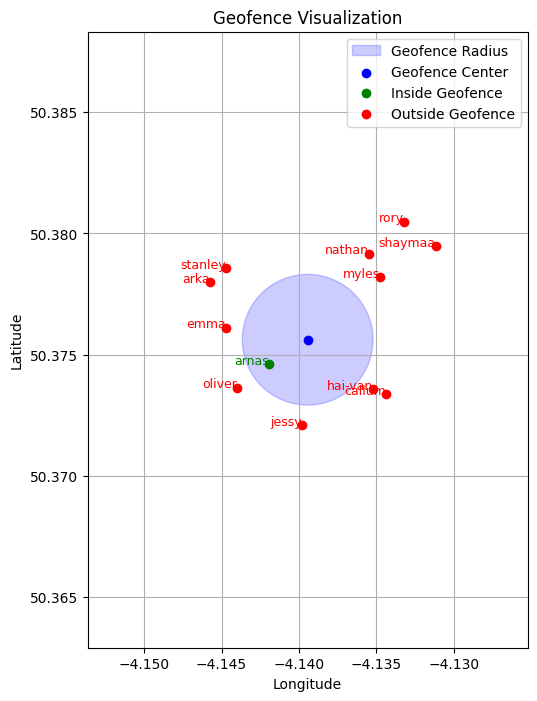

In [44]:
from math import pi, cos, radians
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Load the dataset
data = pd.read_csv("names.csv")

# Geofence parameters
center_lat = 50.375618
center_lon = -4.139433
geofence_radius = 0.3  # km

# Calculate radius in degrees for latitude and longitude
radius_deg_lat = geofence_radius / 111.32
radius_deg_lon = geofence_radius / (111.32 * cos(radians(center_lat)))

# Function to classify points
inside_points = []
outside_points = []

for index, row in data.iterrows():
    point_lat = row['latitude']
    point_lon = row['longitude']

    # Assume is_within_geofence uses proper distance calculation (e.g., Haversine)
    inside, dist = is_within_geofence(center_lat, center_lon, geofence_radius, point_lat, point_lon)

    if inside:
        inside_points.append((point_lat, point_lon, row['name']))
    else:
        outside_points.append((point_lat, point_lon, row['name']))

def plot_geofence_and_points(center_lat, center_lon, radius_km, inside_points, outside_points):
    # Calculate radii again for plotting
    radius_deg_lat = radius_km / 111.32
    radius_deg_lon = radius_km / (111.32 * cos(radians(center_lat)))

    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot the geofence as an ellipse
    geofence_ellipse = Ellipse(
        (center_lon, center_lat),
        width=2 * radius_deg_lon,
        height=2 * radius_deg_lat,
        color='blue', alpha=0.2, label="Geofence Radius"
    )
    ax.add_patch(geofence_ellipse)

    # Plot center
    ax.scatter(center_lon, center_lat, color='blue', label="Geofence Center", zorder=5)

    # Plot points
    for lat, lon, name in inside_points:
        ax.scatter(lon, lat, color='green', label="Inside Geofence" if 'Inside Geofence' not in ax.get_legend_handles_labels()[1] else "", zorder=5)
        ax.text(lon, lat, name, fontsize=9, color='green', ha='right')

    for lat, lon, name in outside_points:
        ax.scatter(lon, lat, color='red', label="Outside Geofence" if 'Outside Geofence' not in ax.get_legend_handles_labels()[1] else "", zorder=5)
        ax.text(lon, lat, name, fontsize=9, color='red', ha='right')

    # Configure plot
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Geofence Visualization")
    
    # Set aspect ratio to display the ellipse correctly
    ax.set_aspect(1.0 / cos(radians(center_lat)), adjustable='box')
    
    # Set limits with margin
    margin = 0.01
    ax.set_xlim(center_lon - radius_deg_lon - margin, center_lon + radius_deg_lon + margin)
    ax.set_ylim(center_lat - radius_deg_lat - margin, center_lat + radius_deg_lat + margin)
    
    ax.legend()
    plt.grid()
    plt.show()

# Call the plotting function
plot_geofence_and_points(center_lat, center_lon, geofence_radius, inside_points, outside_points)
